In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [ ]:
# Step 1: Read the new dataset with 'ss1_group' column
df = pd.read_csv('/new_complete_with_ss1_groups.csv')

In [ ]:
print(df.columns)


Index(['Participant', 'Trial', 'Environment', 'Environment_Type',
       'Chosen_Island', 'Probability', 'Random_Value', 'Reward', 'Score',
       'Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration',
       'Exploitation', 'ss1_score', 'ss1_group'],
      dtype='object')


<ipython-input-47-afa87f6d1a31>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data, x='Environment_Type', y='Win-Stay', hue='ss1_group', palette='Set2', ci=None)


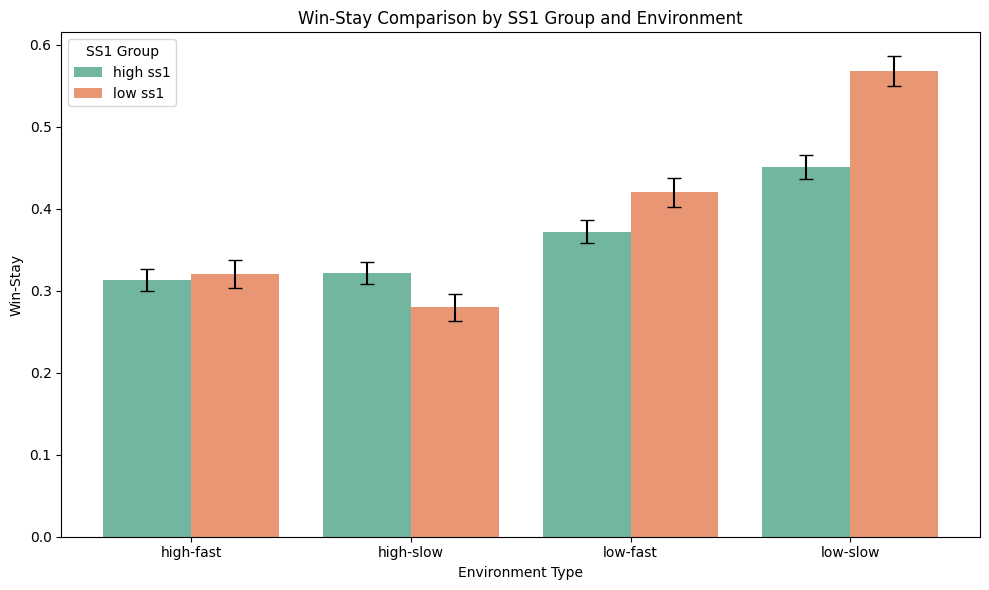

In [ ]:
# Group and calculate means and confidence intervals
plot_data = df.groupby(['Environment_Type', 'ss1_group'])['Win-Stay'].agg(['mean', 'sem']).reset_index()
plot_data.rename(columns={'mean': 'Win-Stay', 'sem': 'CI'}, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Environment_Type', y='Win-Stay', hue='ss1_group', palette='Set2', ci=None)

# Add error bars manually with dynamic position
for i, row in plot_data.iterrows():
    # Adjust the x position for each error bar for better visual alignment
    x_pos = i//2 + (i % 2) * 0.4 - 0.2
    plt.errorbar(x=x_pos, y=row['Win-Stay'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Win-Stay Comparison by SS1 Group and Environment')
plt.ylabel('Win-Stay')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

<ipython-input-48-17ac52819fc2>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data, x='Environment_Type', y='Lose-Shift', hue='ss1_group', palette='Set2', ci=None)


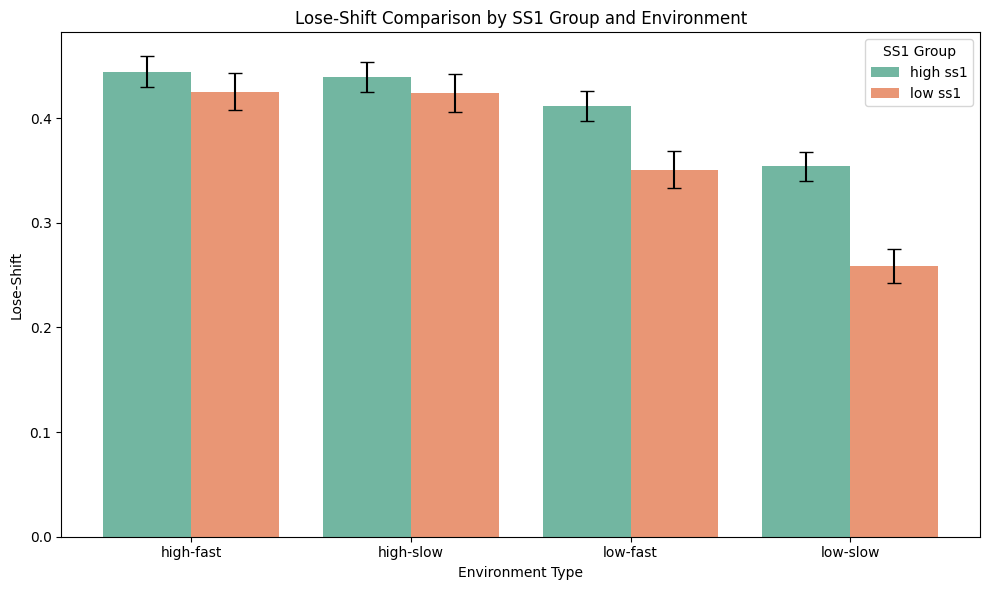

In [ ]:
# Group and calculate means and confidence intervals
plot_data = df.groupby(['Environment_Type', 'ss1_group'])['Lose-Shift'].agg(['mean', 'sem']).reset_index()
plot_data.rename(columns={'mean': 'Lose-Shift', 'sem': 'CI'}, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Environment_Type', y='Lose-Shift', hue='ss1_group', palette='Set2', ci=None)

# Add error bars manually with dynamic position
for i, row in plot_data.iterrows():
    # Adjust the x position for each error bar for better visual alignment
    x_pos = i//2 + (i % 2) * 0.4 - 0.2
    plt.errorbar(x=x_pos, y=row['Lose-Shift'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Lose-Shift Comparison by SS1 Group and Environment')
plt.ylabel('Lose-Shift')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

<ipython-input-49-9a133220af50>:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data_exploration, x='Environment_Type', y='Exploration_Score', hue='ss1_group', palette='Set2', ci=None)


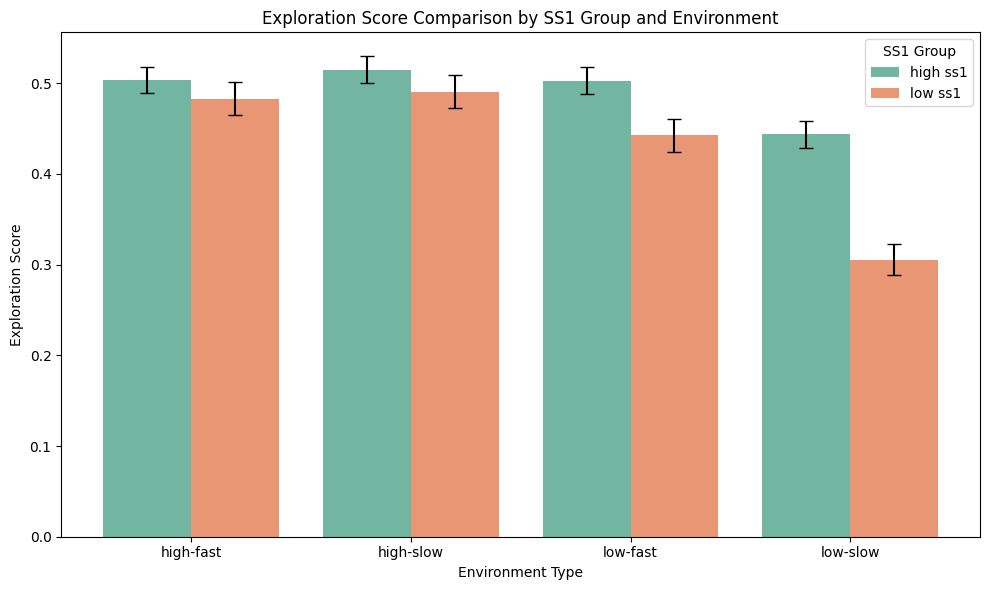

<ipython-input-49-9a133220af50>:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data_exploitation, x='Environment_Type', y='Exploitation_Score', hue='ss1_group', palette='Set2', ci=None)


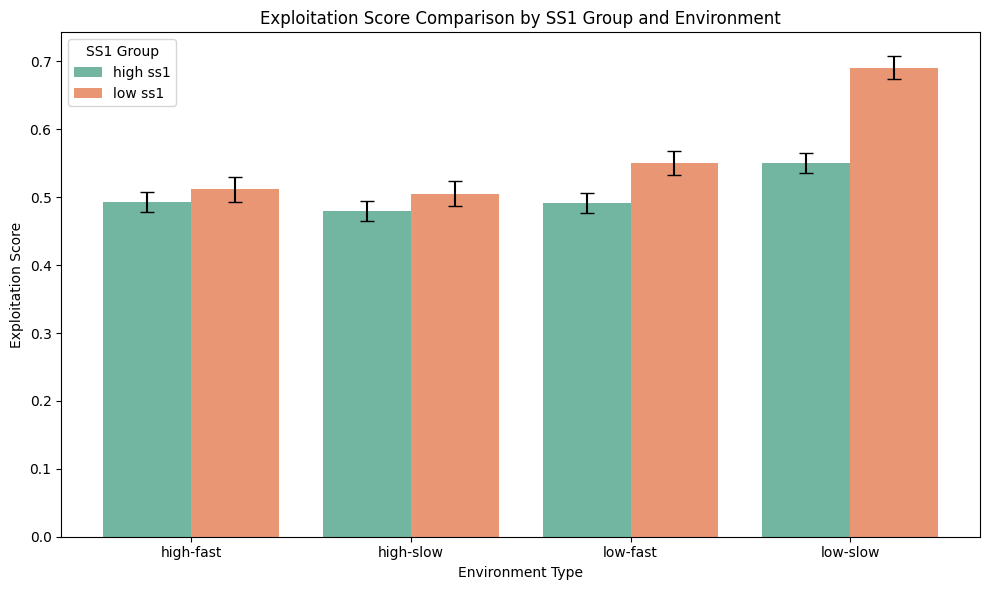

<ipython-input-49-9a133220af50>:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data_reward, x='Environment_Type', y='Reward_Score', hue='ss1_group', palette='Set2', ci=None)


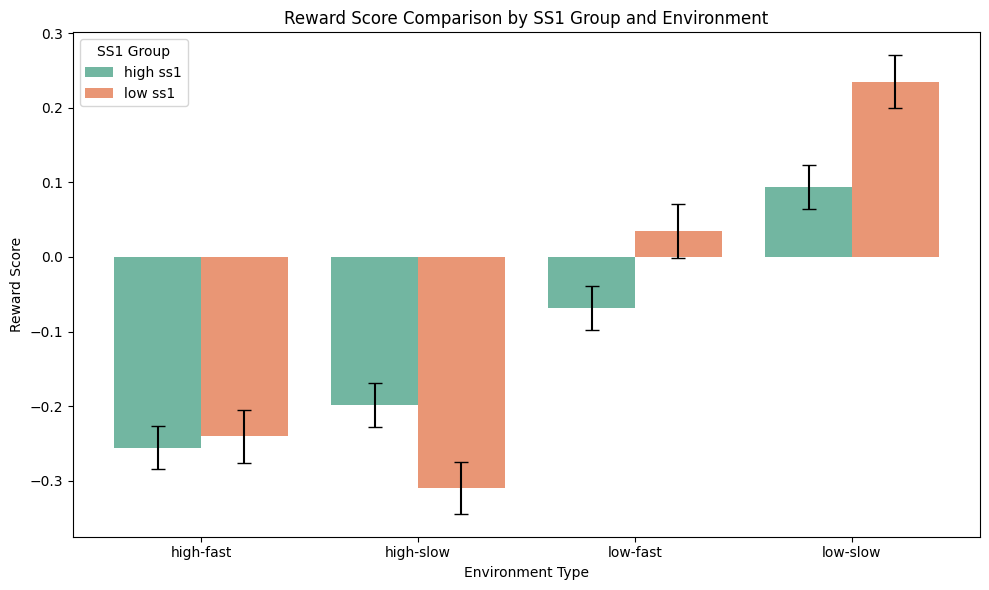

In [ ]:
plot_data_exploration = df.groupby(['Environment_Type', 'ss1_group'])['Exploration'].agg(['mean', 'sem']).reset_index()
plot_data_exploration.rename(columns={'mean': 'Exploration_Score', 'sem': 'CI'}, inplace=True)

plot_data_exploitation = df.groupby(['Environment_Type', 'ss1_group'])['Exploitation'].agg(['mean', 'sem']).reset_index()
plot_data_exploitation.rename(columns={'mean': 'Exploitation_Score', 'sem': 'CI'}, inplace=True)

plot_data_reward = df.groupby(['Environment_Type', 'ss1_group'])['Reward'].agg(['mean', 'sem']).reset_index()
plot_data_reward.rename(columns={'mean': 'Reward_Score', 'sem': 'CI'}, inplace=True)

# Plotting Exploration
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data_exploration, x='Environment_Type', y='Exploration_Score', hue='ss1_group', palette='Set2', ci=None)

# Add error bars for Exploration manually with dynamic position
for i, row in plot_data_exploration.iterrows():
    x_pos = i//2 + (i % 2) * 0.4 - 0.2
    plt.errorbar(x=x_pos, y=row['Exploration_Score'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Exploration Score Comparison by SS1 Group and Environment')
plt.ylabel('Exploration Score')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

# Plotting Exploitation
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data_exploitation, x='Environment_Type', y='Exploitation_Score', hue='ss1_group', palette='Set2', ci=None)

# Add error bars for Exploitation manually with dynamic position
for i, row in plot_data_exploitation.iterrows():
    x_pos = i//2 + (i % 2) * 0.4 - 0.2
    plt.errorbar(x=x_pos, y=row['Exploitation_Score'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Exploitation Score Comparison by SS1 Group and Environment')
plt.ylabel('Exploitation Score')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

# Plotting Reward
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data_reward, x='Environment_Type', y='Reward_Score', hue='ss1_group', palette='Set2', ci=None)

# Add error bars for Reward manually with dynamic position
for i, row in plot_data_reward.iterrows():
    x_pos = i//2 + (i % 2) * 0.4 - 0.2
    plt.errorbar(x=x_pos, y=row['Reward_Score'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Reward Score Comparison by SS1 Group and Environment')
plt.ylabel('Reward Score')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

<ipython-input-50-ca4a0b870bf4>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_data, x='Environment_Type', y='Response_Time', hue='ss1_group', palette='Set2', ci=None)


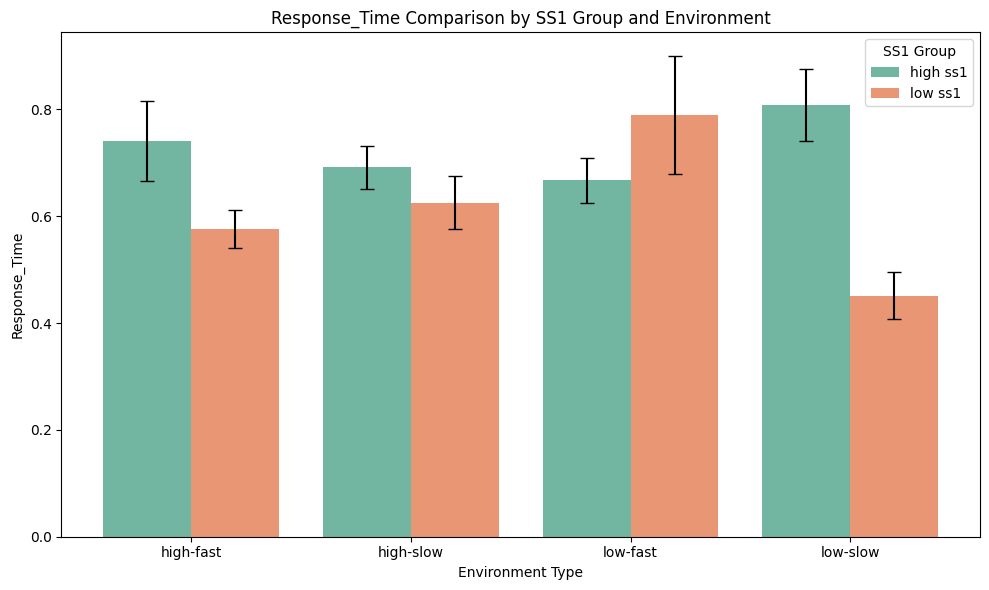

In [ ]:
# Group and calculate means and confidence intervals
plot_data = df.groupby(['Environment_Type', 'ss1_group'])['Response_Time'].agg(['mean', 'sem']).reset_index()
plot_data.rename(columns={'mean': 'Response_Time', 'sem': 'CI'}, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Environment_Type', y='Response_Time', hue='ss1_group', palette='Set2', ci=None)

# Add error bars manually with dynamic position
for i, row in plot_data.iterrows():
    # Adjust the x position for each error bar for better visual alignment
    x_pos = i//2 + (i % 2) * 0.4-0.2
    plt.errorbar(x=x_pos, y=row['Response_Time'], yerr=row['CI'], fmt='none', c='black', capsize=5)

plt.title('Response_Time Comparison by SS1 Group and Environment')
plt.ylabel('Response_Time')
plt.xlabel('Environment Type')
plt.legend(title='SS1 Group')
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv('/new_complete_with_ss1_groups.csv')  # Update path if needed

Unique Environment_Type values: ['high-fast' 'low-slow' 'high-slow' 'low-fast']
Volatility values: ['High Volatility' 'Low Volatility']
SS1 group values: ['low ss1' 'high ss1']


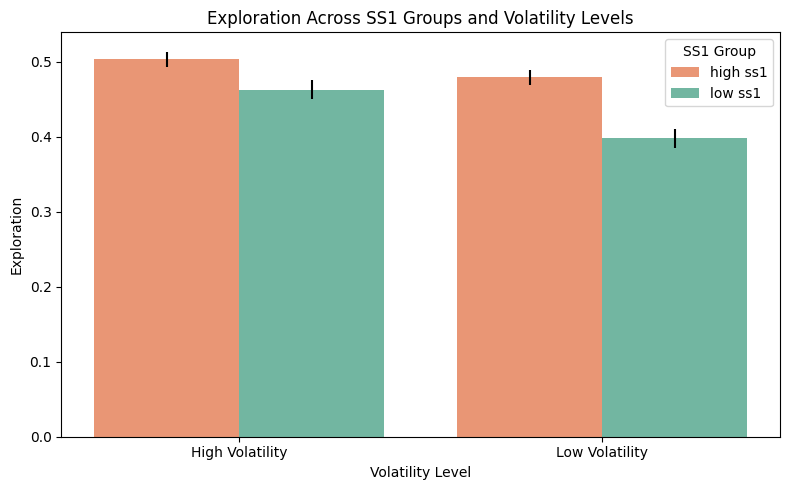

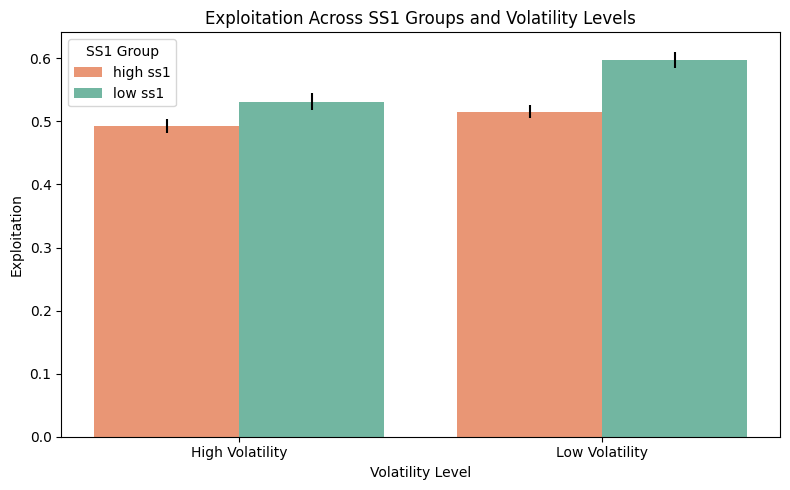

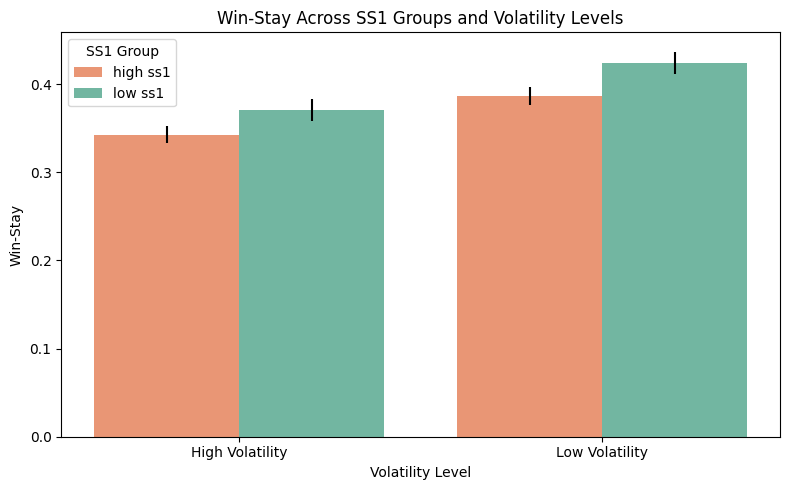

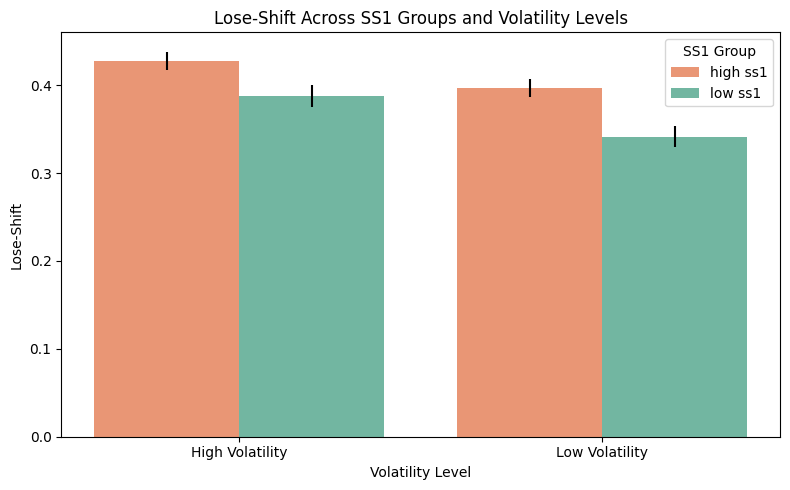

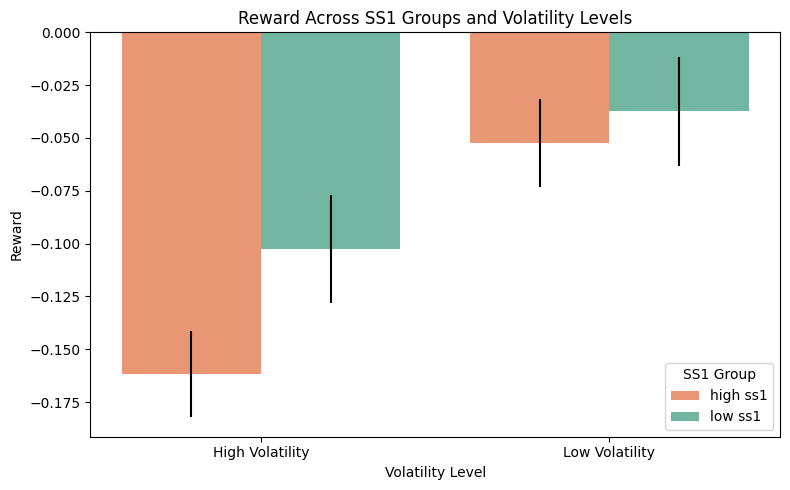

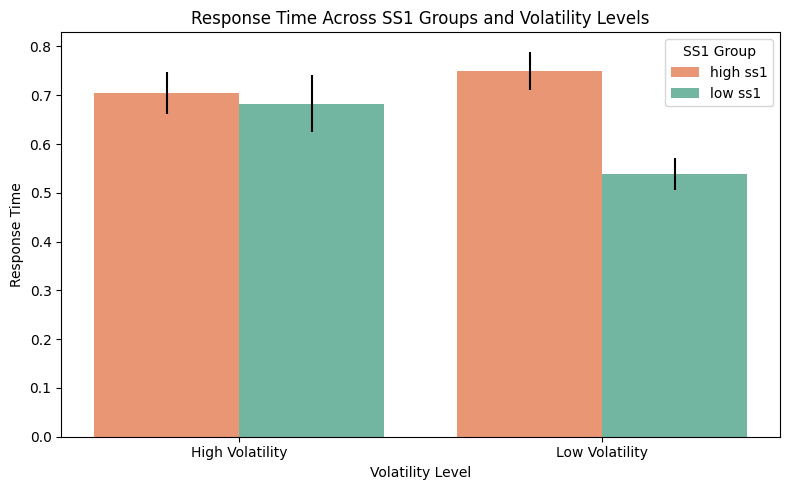

In [ ]:
# Step 1: Inspect unique values in 'Environment_Type'
print("Unique Environment_Type values:", df['Environment_Type'].unique())

# Step 2: Normalize the 'Environment_Type' column (strip whitespace and lowercase if needed)
df['Environment_Type'] = df['Environment_Type'].str.strip().str.lower()

# Step 3: Map 'Environment_Type' to 'Volatility'
volatility_map = {
    'high-fast': 'High Volatility',
    'low-fast': 'High Volatility',
    'high-slow': 'Low Volatility',
    'low-slow': 'Low Volatility'
}

df['Volatility'] = df['Environment_Type'].map(volatility_map)

# Step 4: Check Volatility values again
print("Volatility values:", df['Volatility'].unique())
print("SS1 group values:", df['ss1_group'].unique())

# Step 5: Define metrics to plot
metrics = ['Exploration', 'Exploitation', 'Win-Stay', 'Lose-Shift', 'Reward', 'Response_Time']
titles = ['Exploration', 'Exploitation', 'Win-Stay', 'Lose-Shift', 'Reward', 'Response Time']
colors = {'low ss1': '#66c2a5', 'high ss1': '#fc8d62'}

# Step 6: Plot
for metric, title in zip(metrics, titles):
    plot_data = df.groupby(['Volatility', 'ss1_group'])[metric].agg(['mean', 'sem']).reset_index()
    plot_data.rename(columns={'mean': metric, 'sem': 'CI'}, inplace=True)

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=plot_data, x='Volatility', y=metric, hue='ss1_group',
        palette=colors, errorbar=None
    )
    for i, row in plot_data.iterrows():
        ax.errorbar(
            x=i//2 + (i % 2) * 0.4 - 0.2,
            y=row[metric],
            yerr=row['CI'],
            fmt='none',
            c='black'
        )
    plt.title(f'{title} Across SS1 Groups and Volatility Levels')
    plt.ylabel(title)
    plt.xlabel('Volatility Level')
    plt.legend(title='SS1 Group', loc='best')
    plt.tight_layout()
    plt.show()
